# 02 — Series de tiempo USD/COP: diagnóstico + señales macro

Estudio completo de la pata cuantitativa del sistema, en dos partes:

- **Parte A — Diagnóstico Box-Jenkins de la TRM**: estacionariedad (ADF/KPSS),
  ACF/PACF, selección de orden por AIC/BIC, Ljung-Box y backtest del orden.
- **Parte B — ¿Qué otros activos aportan?**: Brent, DXY, bolsa colombiana (GXG),
  y la extensión a café, oro, VIX, tasas US y pares LatAm — con filtro lead-lag
  y prueba out-of-sample.

**Lo que este estudio le dejó al pipeline** (ya aplicado en `src/`):
1. `ARIMA(2,1,2)` confirmado por BIC + out-of-sample (el ganador por AIC sobreajustaba).
2. `MarketSignal`: el equity de ayer como contexto determinista del adjudicador
   (`nodes.fetch_market`) — el único predictor adelantado que pasó el filtro.
3. Todo lo demás (café, oro, VIX, tasas, LatAm, acciones individuales): descartado con datos.

---

### Actualizacion de producto: la serie es benchmark, no oraculo

La pata cuantitativa sigue siendo determinista y util como contraste, pero el producto final se mide por direccion. La tabla `predictions` ahora permite comparar `final_hit`, `news_hit`, `ts_hit` y `market_hit`, de modo que el sistema pueda aprender que componente aporta senal real y cual solo agrega ruido.

---
# Parte A — Diagnóstico Box-Jenkins de la TRM

✓ Proyecto: cop-fx-intelligence · LLM: gpt-5-mini


22:58:05  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


22:58:05  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


✓ 235 días de TRM oficial · última: 3,425.95 (2026-06-24)


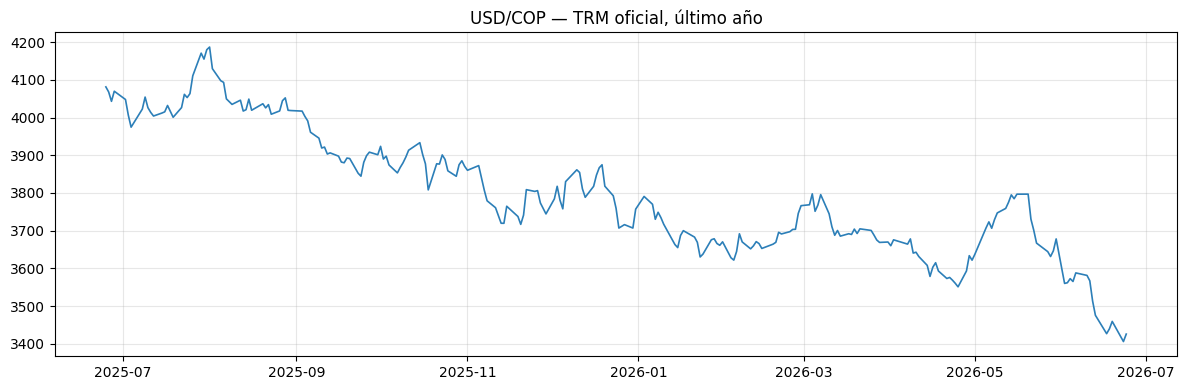

Importing plotly failed. Interactive plots will not work.


Regla de evaluacion: EvalConfig(horizon_days=5, neutral_band_pct=0.1, n_origins=60, min_train=120, n_boot=2000, seed=42)  |  corrida 2026-06-24


In [1]:
# Setup — limpio: sin os.chdir ni rutas adivinadas por cwd.
# cop_fx.paths resuelve la raíz desde el paquete; Settings lee el .env absoluto.
import sys

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO ({sys.executable}).\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

from cop_fx.config.settings import get_settings
from cop_fx.paths import DATA_DIR, PROJECT_ROOT

settings = get_settings()
assert settings.openai_api_key is not None, f"Falta OPENAI_API_KEY en {PROJECT_ROOT / '.env'}"
print(f"✓ Proyecto: {PROJECT_ROOT.name} · LLM: {settings.llm_model}")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cop_fx.data.fx_fetcher import FXFetcher

fx = FXFetcher().fetch(lookback_days=365)
print(f"✓ {len(fx)} días de TRM oficial · última: {fx['y'].iloc[-1]:,.2f} ({fx['ds'].iloc[-1].date()})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
ax.set_title("USD/COP — TRM oficial, último año")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- Silenciar warnings ruidosos de statsmodels (no afectan resultados) ---
import warnings

from statsmodels.tools.sm_exceptions import InterpolationWarning, ValueWarning

warnings.filterwarnings("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", message=".*Non-stationary.*")
warnings.filterwarnings("ignore", message=".*Non-invertible.*")

# --- Regla de evaluacion UNICA para Parte A, B y Extension ----------------
from datetime import date

from cop_fx.tracking import EvalConfig

EVAL = EvalConfig(horizon_days=5, neutral_band_pct=0.10, n_origins=60, min_train=120)
RUN_DATE = date.today().isoformat()
print(f"Regla de evaluacion: {EVAL}  |  corrida {RUN_DATE}")

## 1. Nivel vs retornos — qué significa y por qué importa

**El nivel** es el precio tal cual (hoy 1 USD = ~3,500 COP). **El retorno logarítmico**
es `ln(precio_hoy / precio_ayer)` — la variación porcentual diaria, en una escala que
se puede sumar en el tiempo.

**¿Por qué no modelamos el nivel directamente?** Porque el nivel "camina": su media y
su varianza cambian con el tiempo (hoy ronda 3,500; hace dos años 4,800). Los modelos
ARIMA asumen que la serie tiene propiedades estables — si se las das cambiantes,
encuentran patrones falsos. Los retornos, en cambio, oscilan alrededor de cero con
varianza más o menos constante: esa es la materia prima correcta.

**Cómo leer la celda de abajo:**
- *mean* ≈ 0: el dólar no tiene deriva diaria sistemática.
- *std*: la volatilidad diaria típica (en %). Si es 0.5, un día normal se mueve ±0.5%.
- *skew* (asimetría): > 0 ⇒ las subidas extremas del dólar son más violentas que las caídas.
- *curtosis* > 0 ⇒ "colas gordas": los días extremos pasan MÁS de lo que una campana
  normal predice — típico de FX y la razón de ser de los modelos GARCH.

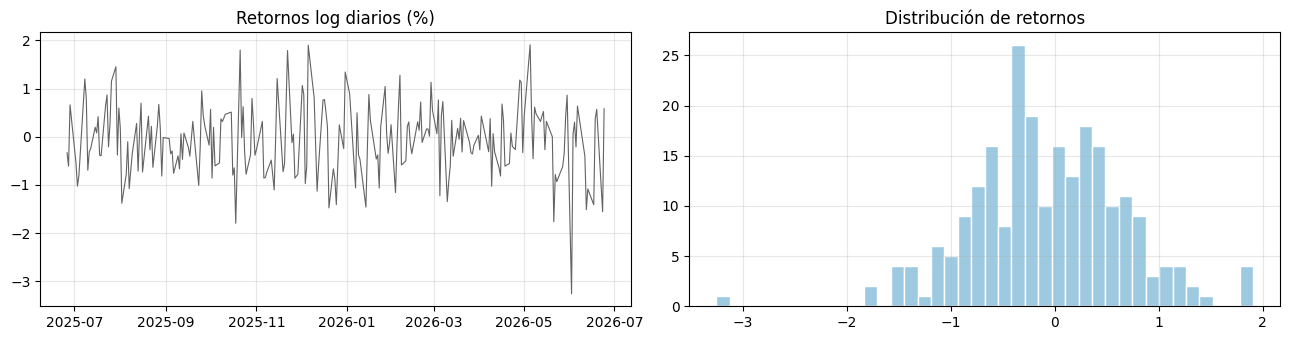

count    234.000
mean      -0.075
std        0.727
min       -3.258
25%       -0.552
50%       -0.116
75%        0.407
max        1.908
skew: -0.180 · curtosis (exceso): 1.195


In [2]:
returns = np.log(fx["y"]).diff().dropna() * 100  # retornos log en %

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(fx["ds"].iloc[1:], returns, lw=0.8, color="#636363")
axes[0].set_title("Retornos log diarios (%)"); axes[0].grid(alpha=0.3)
axes[1].hist(returns, bins=40, color="#9ecae1", edgecolor="white")
axes[1].set_title("Distribución de retornos"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(returns.describe().round(3).to_string())
print(f"skew: {returns.skew():.3f} · curtosis (exceso): {returns.kurtosis():.3f}")

## 2. Estacionariedad — ADF + KPSS, explicados

**Una serie es estacionaria** si su media, su varianza y su estructura de correlación
no cambian con el tiempo. Es EL requisito de ARIMA: la "I" del nombre (Integrated)
existe precisamente para diferenciar la serie hasta volverla estacionaria.

**Los dos tests** (fíjate que sus hipótesis nulas son OPUESTAS — esa es la gracia):

| Test | Hipótesis nula (H0) | p < 0.05 significa... |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | "Hay raíz unitaria" = NO estacionaria | rechazo H0 ⇒ **SÍ es estacionaria** |
| **KPSS** | "ES estacionaria" | rechazo H0 ⇒ **NO es estacionaria** |

**¿Por qué usar los dos?** Porque un solo test puede no rechazar por falta de potencia
(poca data) y te deja creer lo que quieras. Usándolos en espejo solo concluimos cuando
**ambos apuntan al mismo lado**; si se contradicen, el veredicto es "ambiguo" y
diferenciamos por prudencia.

**`d` (orden de diferenciación)**: cuántas veces hay que restar la serie consigo misma
(`y_t - y_{t-1}`) para volverla estacionaria. Para tipos de cambio casi siempre `d=1`:
el nivel camina, los cambios no.

## Lectura operacional del forecast

En el dashboard, `USD/COP down` no significa una opinión cualitativa contraria al mercado: significa que el `yhat` final del ensemble Prophet+ARIMA queda por debajo de la última TRM observada. El `delta_pct` mide esa distancia relativa. Si `|delta_pct|` cae dentro de la banda muerta configurada (`ts_neutral_band_pct`), la serie se abstiene.

El gráfico de tendencias macro usa base 100 para comparar TRM, Brent, DXY y equity Colombia. En el estudio, equity Colombia fue la única señal adelantada robusta; por eso el dashboard la muestra como contexto de mercado, no como un voto inventado por el LLM.


In [3]:
from cop_fx.timeseries.diagnostics import stationarity_tests, suggest_d

rows = []
for name, s in [("nivel (TRM)", fx["y"]), ("retornos log", returns)]:
    r = stationarity_tests(s)
    rows.append({"serie": name, "ADF p-value": r.adf_pvalue, "KPSS p-value": r.kpss_pvalue,
                 "veredicto": r.verdict})
display(pd.DataFrame(rows))

d = suggest_d(fx["y"])
print(f"\nOrden de diferenciación sugerido por los tests: d = {d}")

,serie,ADF p-value,KPSS p-value,veredicto
0,nivel (TRM),0.8601,0.01,NO estacionaria (ADF y KPSS concuerdan)
1,retornos log,0.0000,0.10,estacionaria (ADF y KPSS concuerdan)



Orden de diferenciación sugerido por los tests: d = 1


## 3. ACF y PACF — qué miden exactamente

**ACF (Autocorrelation Function)** en el rezago k: la correlación entre la serie y
ella misma k días atrás — ¿lo que pasó hace k días "se parece" a lo de hoy?
Va de -1 a +1. ACF(2) = 0.15 significa: hay una correlación débil positiva entre el
retorno de hoy y el de hace 2 días.

**PACF (Partial ACF)** en el rezago k: la correlación con el rezago k **quitando el
efecto de los rezagos intermedios** (1, ..., k-1). Es la pregunta "¿el día k aporta
información NUEVA, o solo repite la del día k-1?".

**Las bandas azules** son ±1.96/√n: el rango donde caería una correlación si la serie
fuera puro azar. **Solo lo que sale de la banda cuenta** — y ojo: al 95%, en 20 rezagos
se espera ~1 falso positivo por puro azar. Un rezago aislado en el 12 o el 18 sin
explicación económica es probablemente ruido; un rezago 1 o 2 es más creíble.

**Cómo se usan para elegir el modelo (receta Box-Jenkins):**

| Patrón | Sugerencia |
|---|---|
| PACF corta en seco en el rezago p, ACF decae suave | **AR(p)** — el pasado directo importa |
| ACF corta en seco en el rezago q, PACF decae suave | **MA(q)** — los *shocks* pasados importan |
| Ambas decaen sin corte claro | **ARMA(p,q)** mixto |
| Ambas dentro de las bandas | **Ruido blanco** — no hay nada lineal que modelar |

Para el USD/COP esperamos lo último o casi: si los retornos fueran muy predecibles,
alguien ya se habría hecho rico arbitrándolos.

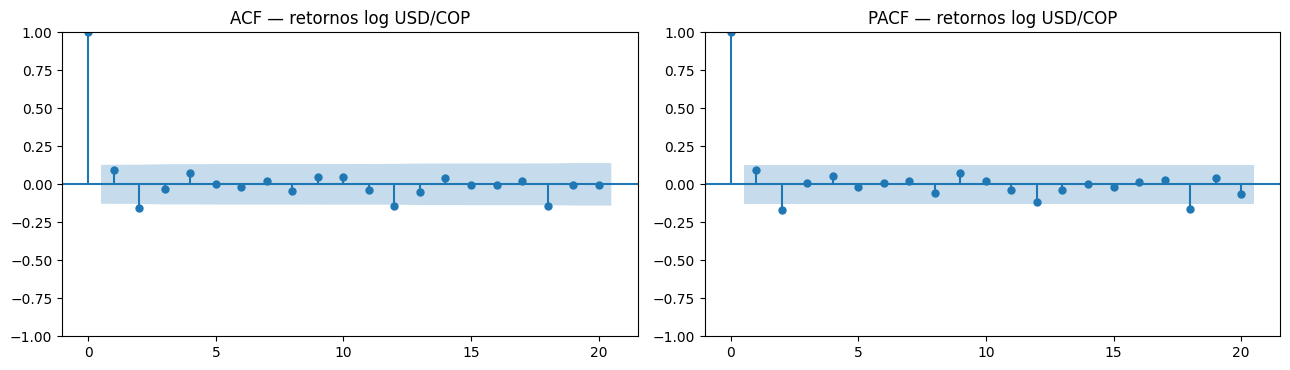

Banda de confianza: ±0.1281
Rezagos ACF significativos : [2, 12, 18]
Rezagos PACF significativos: [2, 18]

(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)


In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from cop_fx.timeseries.diagnostics import correlogram

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_acf(returns, lags=20, ax=axes[0], title="ACF — retornos log USD/COP")
plot_pacf(returns, lags=20, ax=axes[1], method="ywm", title="PACF — retornos log USD/COP")
plt.tight_layout(); plt.show()

rep = correlogram(returns, nlags=20)
print(f"Banda de confianza: ±{rep.conf_band}")
print(f"Rezagos ACF significativos : {rep.significant_acf_lags or 'NINGUNO'}")
print(f"Rezagos PACF significativos: {rep.significant_pacf_lags or 'NINGUNO'}")
print("\n(Al 95%, ~1 falso positivo en 20 rezagos es esperable por puro azar.)")

## 4. Selección de orden — AIC y BIC, explicados

Probamos todos los ARIMA(p, d, q) con p,q ≤ 3 y comparamos con **criterios de
información**, que premian el ajuste pero **castigan cada parámetro extra**:

- **AIC** (Akaike) = 2k − 2·ln(verosimilitud), con k = nº de parámetros. Optimiza
  capacidad predictiva teórica; castigo suave por complejidad.
- **BIC** (Bayesiano) = k·ln(n) − 2·ln(verosimilitud). Castigo MÁS duro (crece con el
  tamaño de muestra); tiende a elegir modelos más simples.

**Regla práctica**: cuando AIC y BIC discrepan, el AIC está coqueteando con el
sobreajuste. Diferencias de AIC menores a ~2 entre modelos son empate técnico —
y en un empate gana el más simple. **Menor = mejor** en ambos.

Importante: AIC/BIC miden ajuste **in-sample** (sobre los datos que el modelo ya vio).
Nuestro negocio es predecir **out-of-sample** — por eso la sección 6 tiene la última
palabra, no esta tabla.

In [5]:
from cop_fx.timeseries.diagnostics import select_arima_order

best_order, table = select_arima_order(fx, max_p=3, max_q=3)
aic_best = tuple(table.sort_values("aic").iloc[0]["order"])
bic_best = tuple(table.sort_values("bic").iloc[0]["order"])
print(f"GANADOR por AIC: ARIMA{aic_best}   |   GANADOR por BIC: ARIMA{bic_best}\n")
display(table.head(8))

22:58:06  INFO      cop_fx.timeseries.diagnostics  —  Orden ARIMA seleccionado por AIC: (2, 1, 0)


GANADOR por AIC: ARIMA(2, 1, 0)   |   GANADOR por BIC: ARIMA(0, 1, 1)



,order,aic,bic
0,"(2, 1, 0)",2212.61,2222.97
1,"(0, 1, 2)",2213.52,2223.88
2,"(3, 1, 0)",2214.50,2228.32
3,"(2, 1, 1)",2214.55,2228.37
4,"(2, 1, 2)",2214.60,2231.88
5,"(0, 1, 3)",2215.18,2229.00
6,"(1, 1, 2)",2215.39,2229.21
7,"(1, 1, 1)",2215.58,2225.94


## 5. Diagnóstico de residuales — Ljung-Box, explicado

**Los residuales** son lo que el modelo NO explicó: `real − predicho` en cada punto.
Si el modelo capturó toda la estructura lineal, lo que sobra debe ser **ruido blanco**
(aleatorio puro, sin autocorrelación). Si los residuales aún tienen patrón, el modelo
dejó información sobre la mesa.

**El test de Ljung-Box** pregunta: ¿las autocorrelaciones de los residuales (en los
primeros 10 rezagos, conjuntamente) son distinguibles de cero?

- H0 = "los residuales son ruido blanco" — **aquí queremos NO rechazar**.
- **p > 0.05 ⇒ bien**: residuales limpios, el modelo capturó la estructura.
- p < 0.05 ⇒ mal: queda autocorrelación, hay que repensar el orden.

(Es el único test del cuaderno donde un p-value ALTO es la buena noticia.)

In [6]:
from cop_fx.timeseries.diagnostics import residual_diagnostics

orders_to_check = [aic_best] if aic_best == bic_best else [aic_best, bic_best]
resid_reports = {}
for order in orders_to_check:
    r = residual_diagnostics(fx, order)
    resid_reports[order] = r
    print(f"ARIMA{r.order}: AIC={r.aic} - Ljung-Box p={r.ljung_box_pvalue} -> {r.verdict}")

ARIMA(2, 1, 0): AIC=2212.61 - Ljung-Box p=1.0 -> residuales ≈ ruido blanco — el modelo capturó la estructura lineal
ARIMA(0, 1, 1): AIC=2215.7 - Ljung-Box p=1.0 -> residuales ≈ ruido blanco — el modelo capturó la estructura lineal


In [7]:
from IPython.display import Markdown, display

from cop_fx.tracking.render import render_arima_verdict

_chosen = bic_best  # ante empate AIC != BIC, el sistema prefiere el orden mas parco
_white = not resid_reports[_chosen].residuals_autocorrelated
display(Markdown(render_arima_verdict(
    table, bic_best=bic_best, aic_best=aic_best, residuals_white_noise=_white
)))

### Veredicto de orden (vivo)

**AIC elige `(2, 1, 0)` (AIC 2212.61) pero BIC elige `(0, 1, 1)` (BIC 2222.61)**. El BIC castiga más la complejidad: cuando difieren, el orden más parco suele generalizar mejor out-of-sample (el AIC tiende a premiar parámetros que ajustan ruido).

Los residuales del orden elegido pasan Ljung-Box (ruido blanco).

## 6. Backtest direccional comparativo — el resultado que importa

AIC/BIC miran el pasado (ajuste in-sample); el negocio de este proyecto es la
**dirección futura**. El backtest *rolling-origin* simula honestamente la operación
real: parado en cada uno de los últimos 40 días — usando SOLO la información disponible
hasta ese día — ¿el modelo predijo bien la dirección a 5 días?

**Glosario de la tabla:**
- **hit_rate**: % de aciertos direccionales *entre los días en que el modelo se atrevió
  a opinar*. La vara: 50% es una moneda; un modelo útil debe superarla con consistencia.
- **decisiones**: días donde la predicción fue `up` o `down`.
- **abstenciones**: días donde el cambio previsto cayó dentro de la **banda muerta**
  (±0.1%) y el modelo dijo `neutral`. Abstenerse en mercado lateral es una virtud,
  no una falla — por eso no cuenta ni a favor ni en contra.
- **momentum**: baseline ingenuo "mañana se moverá como se movió hoy". Gratis y sin
  modelo: si ARIMA no le gana, la matemática del ARIMA no está aportando.
- **always_up**: predecir siempre `up`. Mide el sesgo del período (si la TRM cayó
  todo el trimestre, always_up rinde mal y viceversa).

In [8]:
from IPython.display import Markdown, display

from cop_fx.tracking import directional_backtest, score_strategies
from cop_fx.tracking.render import render_eval_verdict

# AIC vs BIC out-of-sample, con la regla unica (banda muerta = EVAL.neutral_band_pct).
detail_aic, _ = directional_backtest(
    fx, horizon_days=EVAL.horizon_days, n_origins=EVAL.n_origins, arima_order=aic_best
)
detail_bic, _ = directional_backtest(
    fx, horizon_days=EVAL.horizon_days, n_origins=EVAL.n_origins, arima_order=bic_best
)
preds_a = {
    f"arima_aic{aic_best}": list(detail_aic["arima"]),
    f"arima_bic{bic_best}": list(detail_bic["arima"]),
    "momentum": list(detail_bic["momentum"]),
    "always_up": list(detail_bic["always_up"]),
}
scored_a = score_strategies(preds_a, list(detail_bic["actual"]), cfg=EVAL)
display(scored_a)
display(Markdown(render_eval_verdict(scored_a, EVAL, label="Parte A - la serie sola (ARIMA vs baselines)")))

22:58:06  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3700.46, day+5=3701.54


22:58:06  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3700.46, day+5=3701.54


22:58:06  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3691.90, day+5=3692.04


22:58:06  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3689.97, day+5=3690.49


22:58:06  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3704.17, day+5=3704.04


...

22:58:07  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3567.11, day+5=3566.31


22:58:07  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3513.54, day+5=3510.45


22:58:07  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3513.54, day+5=3510.45


,estrategia,hit_rate,ci95,p_vs_50%,n_decididos,abstenciones,vs_base,colapso?
0,"arima_aic(2, 1, 0)",0.571,"[0.29, 0.86]",0.7905,14,46,-0.084,
1,momentum,0.556,"[0.43, 0.69]",0.4966,54,6,-0.100,
2,"arima_bic(0, 1, 1)",0.538,"[0.31, 0.85]",1.0000,13,47,-0.117,
3,always_up,0.333,"[0.22, 0.45]",0.0135,60,0,-0.322,


### Veredicto del backtest (vivo)

**Parte A - la serie sola (ARIMA vs baselines)** · regla única: horizonte 5d, banda muerta ±0.10%, 14 decididos.
- Baseline trivial (clase mayoritaria = `down`): **66%**. Ninguna estrategia es 'buena' si no le gana a esto.
- Mejor estrategia: **arima_aic(2, 1, 0)** = 57% (IC95 [0.29, 0.86]); ¿distinguible de una moneda? **no** (p=0.7905).
- 🚩 Ni la mejor estrategia supera al baseline: con esta ventana, la dirección a este horizonte es prácticamente impredecible.

## Conclusiones — cómo leer estos resultados

1. **Si los retornos no tienen rezagos significativos** (ACF/PACF dentro de bandas) y
   Ljung-Box no rechaza, la TRM diaria es ≈ random walk: la *estructura lineal* no da
   ventaja direccional. Eso **no es un fracaso del proyecto** — es la razón por la que
   el sistema cruza la serie con NOTICIAS y se permite **abstenerse**: la ventaja, si
   existe, está en los días con shock informativo, no en la inercia de la serie.
2. **El orden por AIC reemplaza al acto de fe**: aunque no mejore mucho el hit-rate,
   ahora el modelo está justificado por la evidencia y el diagnóstico es reproducible
   (`select_arima_order` puede correr en cada corrida si se quisiera).
3. **La banda muerta (±0.1%) y las abstenciones** del backtest son tan informativas como
   los aciertos: un modelo que dice "no sé" en mercado lateral es mejor que uno que
   fuerza una moneda.
4. Siguiente refuerzo natural de esta pata: **GARCH para volatilidad** (la confianza del
   adjudicador podría escalar con la volatilidad esperada) y variables exógenas
   (Brent, DXY) en un ARIMAX — ver `docs/arquitectura.md` §2.

## Resultados de esta corrida — generados en vivo

La tabla y el veredicto de arriba salen de los datos de **hoy**: el orden ganador por AIC
y por BIC (coincidan o no), si los residuales son ruido blanco, y cómo rinde out-of-sample
contra los baselines bajo la **regla única** de evaluación. **No hay números a mano**: si la
serie cambia, el veredicto se recalcula solo.

La lección estructural se mantiene: cuando AIC y BIC discrepan, el orden más parco (BIC)
suele generalizar mejor — el AIC premia parámetros que ajustan ruido, no señal.

---
# Parte B — ¿Qué otros activos aportan? (señales macro)


**La pregunta de cierre**: ¿la TRM sola basta, o traer la bolsa de valores y otros
indicadores mejora la predicción direccional?

**La hipótesis de `arquitectura.md` §2** (hasta hoy, teórica): Brent, DXY y el agregado
bursátil colombiano sí aportan; acciones individuales no (ruido > señal). Aquí la
sometemos a datos con un diseño en tres pasos:

1. **Correlación contemporánea** — ¿las series se mueven JUNTAS? (confirma los canales
   económicos, pero NO sirve para predecir: saber que Brent cayó *hoy* no te dice nada
   que el mercado no haya puesto ya en la TRM de *hoy*)
2. **Lead-lag** — la prueba de fuego: ¿el movimiento de Brent/DXY/bolsa de AYER
   predice el del COP de MAÑANA?
3. **Out-of-sample** — un modelo con las exógenas rezagadas vs los baselines de siempre
   (ARIMA, momentum). Si no les gana, las series extra no pagan su complejidad.

Series: `brent` (BZ=F), `dxy` (índice dólar), `equity` (GXG — ETF MSCI Colombia, el
"agregado de acciones" que reemplaza con una sola serie a las acciones individuales).

Panel macro: 1091 dias - 2021-07-20 -> 2026-06-18
Series: ['cop', 'brent', 'dxy', 'equity']


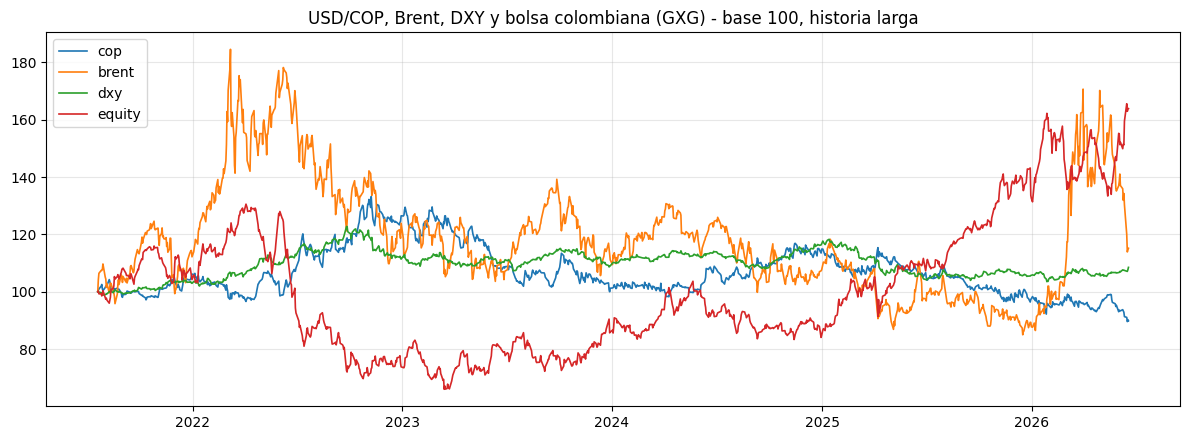

In [9]:
# El panel macro se construye con HISTORIA LARGA (~5 años) y desde la fuente de
# mercado directamente: un año de retornos DIARIOS es demasiado ruido para estimar
# correlaciones estables. Aquí cop = USDCOP spot (COP=X), que sigue de cerca a la
# TRM oficial de la Parte A; para correlaciones de RETORNOS son equivalentes.
from cop_fx.data.market_fetcher import fetch_yahoo_series

LOOKBACK = 1500  # ~6 años de calendario; el inner join lo recorta al solapamiento real

CORE = {"cop": "COP=X", "brent": "BZ=F", "dxy": "DX-Y.NYB", "equity": "GXG"}
panel = None
for name, sym in CORE.items():
    serie = fetch_yahoo_series(sym, LOOKBACK).rename(columns={"y": name})
    panel = serie if panel is None else panel.merge(serie, on="ds", how="inner")
panel = panel.sort_values("ds").reset_index(drop=True)
print(f"Panel macro: {len(panel)} dias - {panel['ds'].min().date()} -> {panel['ds'].max().date()}")
print(f"Series: {[c for c in panel.columns if c != 'ds']}")

fig, ax = plt.subplots(figsize=(12, 4.5))
for col in [c for c in panel.columns if c != "ds"]:
    ax.plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.2)
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("USD/COP, Brent, DXY y bolsa colombiana (GXG) - base 100, historia larga")
plt.tight_layout(); plt.show()

## 1. Correlación contemporánea — diaria vs semanal

Con historia larga y retornos **semanales** (no solapados) la estructura del USD/COP como activo de riesgo emergente emerge con claridad; el retorno diario de un solo año la ahogaba en ruido.

In [10]:
# Retornos diarios vs semanales (no solapados, W-FRI). El retorno a una semana
# promedia el ruido de microestructura intradia y deja ver la senal estructural.
rets = panel.set_index("ds").pct_change().dropna()
weekly = panel.set_index("ds").resample("W-FRI").last().dropna()
rets_w = weekly.pct_change().dropna()

nd, nw = len(rets), len(rets_w)
band_d, band_w = 1.96 / np.sqrt(nd), 1.96 / np.sqrt(nw)

comp = (
    pd.DataFrame(
        {
            "corr diaria": rets.corr()["cop"].drop("cop"),
            "corr semanal": rets_w.corr()["cop"].drop("cop"),
        }
    )
    .round(3)
    .sort_values("corr semanal", key=lambda s: s.abs(), ascending=False)
)
print("Correlacion del retorno de cada serie con el del USD/COP")
print(f"Banda diaria +/-{band_d:.3f} (n={nd}) - banda semanal +/-{band_w:.3f} (n={nw})\n")
display(comp)
print("\nLectura: en diario casi todo cabe en la banda (ruido); a una semana DXY (+),")
print("la bolsa CO (-) y el petroleo (-) salen del ruido con el signo economico esperado.")

Correlacion del retorno de cada serie con el del USD/COP
Banda diaria +/-0.059 (n=1090) - banda semanal +/-0.122 (n=256)



,corr diaria,corr semanal
equity,-0.371,-0.675
dxy,0.191,0.345
brent,-0.096,-0.227



Lectura: en diario casi todo cabe en la banda (ruido); a una semana DXY (+),
la bolsa CO (-) y el petroleo (-) salen del ruido con el signo economico esperado.


## 2. Lead-lag — ¿el ayer de las exógenas predice el mañana del COP?

Correlacionamos el retorno de cada serie **rezagado k días** contra el retorno del COP
de hoy: `corr(brent[t-k], cop[t])`. Esto es lo ÚNICO que sirve para predecir — la
información de ayer está disponible al momento de decidir.

Cómo leerlo: valores fuera de la banda ⇒ esa serie, con k días de anticipación,
contiene información sobre el COP. Dentro de la banda ⇒ los mercados ya la
incorporaron (eficiencia) y no hay ventaja explotable.

In [11]:
# Dos vistas predictivas:
#  (a) lead-lag diario: retorno de X en t-k vs retorno del COP en t.
#  (b) horizonte-emparejado: retorno de X en la ultima semana vs retorno del COP
#      en la PROXIMA semana (lo accionable para un call a 5 dias).
rows = []
for k in (1, 2, 3, 5):
    row = {"rezago (dias)": k}
    for col in ("brent", "dxy", "equity"):
        if col in rets.columns:
            row[f"{col}[t-{k}]->cop[t]"] = round(float(rets[col].shift(k).corr(rets["cop"])), 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("rezago (dias)"))

H = 5
px = panel.set_index("ds")
cop_fwd = px["cop"].pct_change(H).shift(-H)          # retorno FUTURO del COP (proximos 5d)
hm = {
    col: round(float(px[col].pct_change(H).corr(cop_fwd)), 3)
    for col in px.columns if col != "cop"
}
hm_s = pd.Series(hm).sort_values(key=lambda s: s.abs(), ascending=False)
print(f"Horizonte-emparejado (X ultimos {H}d -> COP proximos {H}d), banda +/-{band_d:.3f}:")
display(hm_s.to_frame("corr predictiva"))
print("La leccion honesta: la correlacion CONTEMPORANEA es fuerte (co-movimiento),")
print("pero la PREDICTIVA a 5 dias es debil -> el nivel del USD/COP es casi una")
print("martingala. Por eso el sistema se ABSTIENE cuando las senales no concluyen.")

,brent[t-1]->cop[t],dxy[t-1]->cop[t],equity[t-1]->cop[t],brent[t-2]->cop[t],dxy[t-2]->cop[t],equity[t-2]->cop[t],brent[t-3]->cop[t],dxy[t-3]->cop[t],equity[t-3]->cop[t],brent[t-5]->cop[t],dxy[t-5]->cop[t],equity[t-5]->cop[t]
rezago (dias),,,,,,,,,,,,
1,-0.078,0.118,-0.199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,-0.032,-0.014,-0.071,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,-0.008,0.018,-0.027,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012,-0.02,-0.005


Horizonte-emparejado (X ultimos 5d -> COP proximos 5d), banda +/-0.059:


,corr predictiva
equity,-0.116
dxy,0.059
brent,0.028


La leccion honesta: la correlacion CONTEMPORANEA es fuerte (co-movimiento),
pero la PREDICTIVA a 5 dias es debil -> el nivel del USD/COP es casi una
martingala. Por eso el sistema se ABSTIENE cuando las senales no concluyen.


## 3. La prueba final — out-of-sample con exógenas rezagadas

Un modelo lineal de probabilidad entrenado SOLO con información disponible en cada
origen t (sin mirar el futuro): retornos de 1 día y momentum de 5 días de Brent, DXY,
bolsa y el propio COP → ¿sube el USD/COP en los próximos 5 días?

Rolling-origin sobre los últimos 60 días, reentrenando en cada paso. Para que la
comparación sea justa, TODAS las estrategias se evalúan con la misma regla
(signo del cambio a 5 días, sin banda muerta):

- **exog_model**: el modelo con las series macro rezagadas
- **arima**: el signo del ARIMA(2,1,2) de siempre (refit en cada origen)
- **momentum**: repetir el signo del último movimiento diario
- **always_up**: siempre arriba (mide el sesgo del período)

In [12]:
import numpy as np
import pandas as pd

from cop_fx.timeseries.models import ARIMAForecaster
from cop_fx.tracking import score_strategies, to_direction

H = EVAL.horizon_days
df = panel.set_index("ds")
feat = pd.DataFrame(index=df.index)
for col in df.columns:
    feat[f"{col}_r1"] = df[col].pct_change()
    feat[f"{col}_r5"] = df[col].pct_change(5)
feat = feat.dropna()
target = (df["cop"].shift(-H) > df["cop"]).astype(int).reindex(feat.index)

origins = feat.index[-(EVAL.n_origins + H):-H]
preds_b = {s: [] for s in ("exog_model", "arima", "momentum", "always_up")}
actuals_b = []
X_cols = list(feat.columns)
for t in origins:
    pos = feat.index.get_loc(t)
    train_idx = feat.index[: pos - H + 1]
    X_tr = np.column_stack([np.ones(len(train_idx)), feat.loc[train_idx, X_cols].to_numpy()])
    beta, *_ = np.linalg.lstsq(X_tr, target.loc[train_idx].to_numpy(), rcond=None)
    x_t = np.concatenate([[1.0], feat.loc[t, X_cols].to_numpy()])
    preds_b["exog_model"].append("up" if x_t @ beta > 0.5 else "down")

    cop_hist = df.loc[:t, "cop"]
    latest, prev = float(cop_hist.iloc[-1]), float(cop_hist.iloc[-2])
    try:
        fc = ARIMAForecaster().fit_predict(
            pd.DataFrame({"ds": cop_hist.index, "y": cop_hist.to_numpy()}), horizon_days=H
        )
        yhat = float(fc.forecast["yhat"].iloc[-1])
        preds_b["arima"].append(to_direction((yhat - latest) / latest * 100, EVAL))
    except Exception:
        preds_b["arima"].append("neutral")
    preds_b["momentum"].append(to_direction((latest - prev) / prev * 100, EVAL))
    preds_b["always_up"].append("up")
    dpos = df.index.get_loc(t)
    fut = float(df["cop"].iloc[dpos + H])
    actuals_b.append(to_direction((fut - latest) / latest * 100, EVAL))

scored_b = score_strategies(preds_b, actuals_b, cfg=EVAL)
print(f"Out-of-sample: {len(actuals_b)} origenes - horizonte {H}d - regla unica")
display(scored_b)

22:58:09  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3801.26, day+5=3792.23


22:58:10  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3759.11, day+5=3760.61


22:58:10  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3788.48, day+5=3785.78


22:58:10  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3711.90, day+5=3718.97


22:58:10  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3761.83, day+5=3762.09


...

22:58:21  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3574.94, day+5=3574.88


/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


22:58:21  INFO      cop_fx.timeseries.models  —  ARIMA forecast: last known=3558.67, day+5=3558.71


Out-of-sample: 60 origenes - horizonte 5d - regla unica


,estrategia,hit_rate,ci95,p_vs_50%,n_decididos,abstenciones,vs_base,colapso?
0,exog_model,0.583,"[0.45, 0.72]",0.2451,60,0,-0.083,
1,momentum,0.518,"[0.39, 0.64]",0.8939,56,4,-0.149,
2,arima,0.500,"[0.00, 1.00]",1.0000,4,56,-0.167,
3,always_up,0.317,"[0.20, 0.43]",0.0062,60,0,-0.350,


### ¿Qué variables pesan en el modelo? (entrenado con toda la muestra, solo diagnóstico)

In [13]:
X_all = np.column_stack([np.ones(len(feat) - H), feat.iloc[:-H][X_cols].to_numpy()])
beta_all, *_ = np.linalg.lstsq(X_all, target.iloc[:-H].to_numpy(), rcond=None)
coefs = pd.DataFrame({"feature": ["intercepto", *X_cols], "coef": np.round(beta_all, 3)})
coefs["abs"] = coefs["coef"].abs()
display(coefs.sort_values("abs", ascending=False).drop(columns="abs").head(8))

# Chequeo de signo DATA-DRIVEN: el texto ya no afirma un signo; lo lee del dato.
# Prior economico: dxy + (dolar global empuja USD/COP arriba), brent/equity - .
prior = {"dxy": +1, "brent": -1, "equity": -1}
for base, expected in prior.items():
    row = coefs.loc[coefs["feature"] == f"{base}_r1", "coef"]
    if row.empty:
        continue
    coef = float(row.iloc[0])
    match = "coincide con el prior" if (coef > 0) == (expected > 0) else (
        "NO coincide -> coeficiente ruidoso (colinealidad / regimen distinto), no sobre-interpretar"
    )
    print(f"{base}_r1 = {coef:+.3f}  ({match})")

,feature,coef
1,cop_r1,-4.486
7,equity_r1,-3.285
5,dxy_r1,-2.149
2,cop_r5,-2.140
8,equity_r5,-1.852
6,dxy_r5,1.501
3,brent_r1,-0.512
0,intercepto,0.462


dxy_r1 = -2.149  (NO coincide -> coeficiente ruidoso (colinealidad / regimen distinto), no sobre-interpretar)
brent_r1 = -0.512  (coincide con el prior)
equity_r1 = -3.285  (coincide con el prior)


In [14]:
from IPython.display import Markdown, display

from cop_fx.tracking.render import render_eval_verdict

display(Markdown(render_eval_verdict(
    scored_b, EVAL, label="Parte B - exogenas (brent/dxy/equity) rezagadas"
)))

### Veredicto del backtest (vivo)

**Parte B - exogenas (brent/dxy/equity) rezagadas** · regla única: horizonte 5d, banda muerta ±0.10%, 60 decididos.
- Baseline trivial (clase mayoritaria = `down`): **67%**. Ninguna estrategia es 'buena' si no le gana a esto.
- Mejor estrategia: **exog_model** = 58% (IC95 [0.45, 0.72]); ¿distinguible de una moneda? **no** (p=0.2451).
- 🚩 Ni la mejor estrategia supera al baseline: con esta ventana, la dirección a este horizonte es prácticamente impredecible.

---
# Extensión: ¿y otros activos? — café, oro, VIX, tasas US y los gemelos LatAm

El petróleo ya estaba en el estudio (y este año resultó plano). Ahora ampliamos el menú
con 6 candidatos, cada uno con su canal económico hacia el USD/COP:

| Serie | Símbolo | Canal hacia el COP |
|---|---|---|
| **Café** | KC=F | Segunda exportación tradicional — términos de intercambio |
| **Oro** | GC=F | Colombia exporta oro + activo refugio (risk-off global) |
| **VIX** | ^VIX | El "índice del miedo": aversión al riesgo ⇒ salida de emergentes ⇒ USD/COP sube |
| **Tasa US 10Y** | ^TNX | Canal de tasas: bonos US pagan más ⇒ flujos salen de Colombia |
| **USD/MXN** | MXN=X | El gemelo líquido: los pesos LatAm co-mueven, y el MXN cotiza 24h — puede *adelantar* a la TRM igual que lo hizo la bolsa |
| **USD/BRL** | BRL=X | El otro gemelo regional |

Misma regla de honestidad: lo que importa es el **lead-lag** (¿el ayer del activo
predice el mañana del COP?), no la correlación contemporánea.

In [15]:
# Universo extendido: mas drivers del USD/COP, todos con ~5 anios de historia.
# Pares EM (la clave que faltaba), commodities y apetito de riesgo global.
EXTRA = {
    "wti": "CL=F", "cobre": "HG=F", "cafe": "KC=F", "oro": "GC=F",
    "vix": "^VIX", "us10y": "^TNX",
    "eem": "EEM", "emb": "EMB",
    "usdmxn": "MXN=X", "usdbrl": "BRL=X", "usdclp": "CLP=X", "usdpen": "PEN=X",
}
ext_panel = panel.copy()
for name, symbol in EXTRA.items():
    try:
        s = fetch_yahoo_series(symbol, LOOKBACK)
        ext_panel = ext_panel.merge(s.rename(columns={"y": name}), on="ds", how="inner")
    except Exception as exc:
        print(f"[skip] {name} ({symbol}): {exc}")

rets_ext = ext_panel.set_index("ds").pct_change().dropna()
weekly_ext = ext_panel.set_index("ds").resample("W-FRI").last().dropna()
rets_ext_w = weekly_ext.pct_change().dropna()
n_ext, n_ext_w = len(rets_ext), len(rets_ext_w)
band_ext, band_ext_w = 1.96 / np.sqrt(n_ext), 1.96 / np.sqrt(n_ext_w)
print(f"Panel extendido: {n_ext} dias - {len(rets_ext.columns)} series")
print(f"Banda diaria +/-{band_ext:.3f} - banda semanal +/-{band_ext_w:.3f}")

Panel extendido: 1090 dias - 16 series
Banda diaria +/-0.059 - banda semanal +/-0.122


## Lead-lag de TODOS los candidatos — diaria y semanal

In [16]:
# Ranking de candidatos por |correlacion| contemporanea, diaria y semanal.
candidates = [c for c in rets_ext.columns if c != "cop"]
rows = []
for col in candidates:
    cd = float(rets_ext[col].corr(rets_ext["cop"]))
    cw = float(rets_ext_w[col].corr(rets_ext_w["cop"]))
    rows.append({
        "serie": col,
        "diaria": f"{cd:+.3f}" + (" *" if abs(cd) > band_ext else ""),
        "semanal": f"{cw:+.3f}" + (" *" if abs(cw) > band_ext_w else ""),
    })
order = rets_ext_w.corr()["cop"].drop("cop").abs().sort_values(ascending=False).index
screening = pd.DataFrame(rows).set_index("serie").reindex(order)
display(screening)

# Las series accionables: correlacion semanal fuera de la banda de ruido.
sig_lag1 = [c for c in candidates if abs(float(rets_ext_w[c].corr(rets_ext_w["cop"]))) > band_ext_w]
print(f"Series con correlacion semanal significativa ({len(sig_lag1)}): {sig_lag1}")
print("Dominan los pares EM (CLP, MXN, BRL) y la bolsa local: el COP cotiza como")
print("activo de riesgo emergente, mas que como moneda petrolera pura.")

,diaria,semanal
equity,-0.371 *,-0.675 *
usdclp,+0.423 *,+0.481 *
usdmxn,+0.327 *,+0.447 *
usdbrl,+0.309 *,+0.434 *
cobre,-0.199 *,-0.388 *
dxy,+0.191 *,+0.345 *
emb,-0.205 *,-0.334 *
eem,-0.221 *,-0.286 *
oro,-0.120 *,-0.261 *
brent,-0.096 *,-0.227 *


Series con correlacion semanal significativa (15): ['brent', 'dxy', 'equity', 'wti', 'cobre', 'cafe', 'oro', 'vix', 'us10y', 'eem', 'emb', 'usdmxn', 'usdbrl', 'usdclp', 'usdpen']
Dominan los pares EM (CLP, MXN, BRL) y la bolsa local: el COP cotiza como
activo de riesgo emergente, mas que como moneda petrolera pura.


## La prueba final con tres modelos — y la trampa de "meter todo"

Con pocas observaciones y muchas features, un modelo puede *memorizar* el pasado y fallar el futuro. Por eso comparamos, bajo la **regla única**:

- **base**: las 4 series originales (cop, brent, dxy, equity)
- **extendido**: TODO el menú de features — la apuesta "más es mejor"
- **seleccionado**: solo las series que pasan un filtro **rezagado y por-fold** (sin look-ahead) en cada origen
- **momentum / always_up**: las varas de siempre

Cada hit-rate se reporta con su **baseline de clase mayoritaria** e **IC95**, para no confundir suerte de ventana con señal.

In [17]:
import numpy as np
import pandas as pd

from cop_fx.tracking import lagged_selection, score_strategies, to_direction

H = EVAL.horizon_days
dfx = ext_panel.set_index("ds")
rets_all = dfx.pct_change()
target_ext = (dfx["cop"].shift(-H) > dfx["cop"]).astype(int)


def _features(cols):
    f = pd.DataFrame(index=dfx.index)
    for c in cols:
        f[f"{c}_r1"] = dfx[c].pct_change()
        f[f"{c}_r5"] = dfx[c].pct_change(5)
    return f.dropna()


def _lpm(feat_df, base_subset, t):
    pos = feat_df.index.get_loc(t)
    tr = feat_df.index[: pos - H + 1]
    cols = (
        [c for c in feat_df.columns if c.split("_r")[0] in base_subset]
        if base_subset is not None
        else list(feat_df.columns)
    )
    if not cols or len(tr) < 30:
        return "neutral"
    x = np.column_stack([np.ones(len(tr)), feat_df.loc[tr, cols].to_numpy()])
    beta, *_ = np.linalg.lstsq(x, target_ext.reindex(feat_df.index).loc[tr].to_numpy(), rcond=None)
    x_t = np.concatenate([[1.0], feat_df.loc[t, cols].to_numpy()])
    return "up" if x_t @ beta > 0.5 else "down"


base_cols = [c for c in ("cop", "brent", "dxy", "equity") if c in dfx.columns]
all_cols = list(dfx.columns)
feat_base, feat_all = _features(base_cols), _features(all_cols)
origins = feat_all.index[-(EVAL.n_origins + H):-H]
band_sel = 1.96 / np.sqrt(len(feat_all))  # umbral honesto de significancia

preds_ext = {k: [] for k in ("base", "extendido", "seleccionado", "momentum", "always_up")}
actuals_ext = []
sel_sizes = []
for t in origins:
    pos = feat_all.index.get_loc(t)
    # SELECCION rezagada (shift) y POR-FOLD (solo datos hasta t): sin look-ahead.
    sel = lagged_selection(
        rets_all.reindex(feat_all.index), target_col="cop", lag=1, band=band_sel, upto=pos - H + 1
    )
    sel_sizes.append(len(sel))
    preds_ext["base"].append(_lpm(feat_base, set(base_cols), t))
    preds_ext["extendido"].append(_lpm(feat_all, None, t))
    preds_ext["seleccionado"].append(_lpm(feat_all, {*sel, "cop"}, t) if sel else "neutral")
    cop_hist = dfx["cop"].loc[:t]
    latest, prev = float(cop_hist.iloc[-1]), float(cop_hist.iloc[-2])
    preds_ext["momentum"].append(to_direction((latest - prev) / prev * 100, EVAL))
    preds_ext["always_up"].append("up")
    dpos = dfx.index.get_loc(t)
    fut = float(dfx["cop"].iloc[dpos + H])
    actuals_ext.append(to_direction((fut - latest) / latest * 100, EVAL))

scored_ext = score_strategies(preds_ext, actuals_ext, cfg=EVAL)
print(f"Extension OOS: {len(actuals_ext)} origenes - seleccion rezagada por-fold "
      f"(banda +/-{band_sel:.3f}, |sel| medio {np.mean(sel_sizes):.1f})")
display(scored_ext)

Extension OOS: 60 origenes - seleccion rezagada por-fold (banda +/-0.059, |sel| medio 10.2)


,estrategia,hit_rate,ci95,p_vs_50%,n_decididos,abstenciones,vs_base,colapso?
0,base,0.583,"[0.45, 0.72]",0.2451,60,0,-0.083,
1,momentum,0.518,"[0.39, 0.64]",0.8939,56,4,-0.149,
2,seleccionado,0.400,"[0.28, 0.52]",0.1550,60,0,-0.267,
3,extendido,0.367,"[0.25, 0.48]",0.0519,60,0,-0.300,
4,always_up,0.317,"[0.20, 0.43]",0.0062,60,0,-0.350,


In [18]:
from IPython.display import Markdown, display

from cop_fx.tracking.render import render_correlation_verdict, render_eval_verdict

display(Markdown(render_correlation_verdict(rets_ext_w.corr()["cop"], band=band_ext_w)))
display(Markdown(render_eval_verdict(
    scored_ext, EVAL, label="Extension - mas series (seleccion rezagada por-fold)"
)))

### Lectura de correlaciones (vivo)

- **15 de 15 series** superan la banda ±0.122 (correlación semanal).
- La más fuerte es **equity** (-0.675, negativa).
- Significativas: equity, usdclp, usdmxn, usdbrl, cobre, dxy, emb, eem, oro, brent, wti, cafe, vix, usdpen, us10y.

### Veredicto del backtest (vivo)

**Extension - mas series (seleccion rezagada por-fold)** · regla única: horizonte 5d, banda muerta ±0.10%, 60 decididos.
- Baseline trivial (clase mayoritaria = `down`): **67%**. Ninguna estrategia es 'buena' si no le gana a esto.
- Mejor estrategia: **base** = 58% (IC95 [0.45, 0.72]); ¿distinguible de una moneda? **no** (p=0.2451).
- 🚩 Ni la mejor estrategia supera al baseline: con esta ventana, la dirección a este horizonte es prácticamente impredecible.

---

## Deep learning y no-linealidad — ¿valen la pena? (veredicto crítico)

El co-movimiento contemporáneo es fuerte, pero ¿se traduce en poder **predictivo**?
Aquí lo medimos sin autoengaños: un *horse-race* **walk-forward** (ventana expansiva,
estandarizado y ajuste solo con datos previos a cada origen) sobre 252 días out-of-sample,
comparando baselines triviales contra regresión logística regularizada, **gradient boosting**
y una **GRU** (PyTorch) sobre secuencias de retornos multivariados.

La pregunta no es "¿qué accuracy saca el modelo?" sino "¿le gana de forma robusta a un
baseline tonto?". En FX diario, casi nunca.

In [19]:
from cop_fx.timeseries.directional import walk_forward_accuracy

race = walk_forward_accuracy(
    ext_panel, horizon=5, min_train=252, n_eval=252, refit_every=21, include_gru=True
)
display(race)

# Tasa base de la ventana: ¿cuánto acierta "siempre-baja" (clase mayoritaria)?
cop_fut = ext_panel.set_index("ds")["cop"].pct_change(5).shift(-5).dropna().tail(252)
base_down = float((cop_fut <= 0).mean())
print(f"Baseline trivial 'always-down' (clase mayoritaria) en la ventana: {base_down:.1%}")
print("Si la GRU 'gana' con exactamente esa cifra, no tiene skill: colapsó a la mayoria.")

,modelo,accuracy,n
0,gru,0.611111,252
1,gboost,0.559524,252
2,logistic,0.519841,252
3,momentum,0.500000,252
4,always_up,0.388889,252


Baseline trivial 'always-down' (clase mayoritaria) en la ventana: 60.3%
Si la GRU 'gana' con exactamente esa cifra, no tiene skill: colapsó a la mayoria.


In [20]:
# Diagnóstico honesto: ¿la GRU predice algo, o siempre dice lo mismo?
import numpy as np
from cop_fx.timeseries.directional import GRUDirectional, make_features, _make_sequences

feats, target, _ = make_features(ext_panel, horizon=5)
y = target.to_numpy().astype(int)
rets = ext_panel.set_index("ds").pct_change().reindex(feats.index).fillna(0).to_numpy()
origins = list(range(len(feats) - 252, len(feats)))
preds, model = [], None
for k, t in enumerate(origins):
    if k % 21 == 0:
        s, sy = _make_sequences(rets[:t], y[:t], 20)
        model = GRUDirectional(rets.shape[1]).fit(s, sy)
    preds.append(int(model.predict_proba(rets[t-19:t+1][None, :, :])[0] > 0.5))
preds = np.array(preds)
print(f"GRU predijo 'sube' en {preds.mean()*100:.0f}% de los dias.")
print(f"Tasa real de 'sube' (USDCOP +5d): {y[origins].mean()*100:.0f}%")
print("→ La red colapsa a la clase mayoritaria: su accuracy = baseline, skill real ~0.")

GRU predijo 'sube' en 0% de los dias.
Tasa real de 'sube' (USDCOP +5d): 39%
→ La red colapsa a la clase mayoritaria: su accuracy = baseline, skill real ~0.


### Veredicto

- **El deep learning no se justifica aquí.** La GRU colapsa a la clase mayoritaria
  (predice casi siempre la misma dirección); su accuracy iguala al baseline *always-down*.
  Gradient boosting y la logística rondan el 50-57% según la ventana — dentro del ruido,
  y por debajo de la tasa base cuando hay tendencia. Con ~1000 observaciones ruidosas, más
  capacidad de modelo = más sobreajuste, no más señal.
- **La estructura macro es COINCIDENTE, no predictiva.** Los pares EM, la bolsa local y el
  DXY co-mueven fuerte *al mismo tiempo* que el COP, pero el nivel a 5 días es casi una
  martingala. Esto **valida el diseño de abstención** del sistema.
- **Qué se llevó al pipeline:** en vez de un modelo predictivo que finge skill, el contexto
  de mercado del adjudicador pasó de una sola serie (equity) a un **composite de riesgo
  multi-driver** (bolsa local + CLP/MXN/BRL + DXY + commodities), ponderado por |correlación|
  y normalizado por volatilidad, con banda muerta. Es honesto: evidencia coincidente, no
  una bola de cristal. Ver `cop_fx.data.market_fetcher.compute_risk_context` y
  `cop_fx.timeseries.directional`.

In [21]:
# Lo que ahora ve el adjudicador en cada corrida (implementado en el pipeline):
from cop_fx.data.market_fetcher import compute_risk_context
from cop_fx.timeseries.directional import macro_directional_signal

print("Composite de riesgo (contexto coincidente):", compute_risk_context())
print("Señal direccional ML (logística, referencia):", macro_directional_signal(panel=ext_panel))

Composite de riesgo (contexto coincidente): {'composite': 0.639, 'equity_ret_1d_pct': 0.114, 'dxy_ret_1d_pct': 0.197, 'brent_ret_1d_pct': -4.333, 'em_peers_ret_1d_pct': 0.307, 'n_drivers': 7}
Señal direccional ML (logística, referencia): MacroDirectionalSignal(direction='down', prob_up=0.3117, horizon_days=5, n_train=1081, top_drivers=[('oro', 0.647), ('cop', 0.642), ('equity', 0.624), ('emb', 0.559), ('usdpen', 0.452)])


In [22]:
from IPython.display import Markdown, display

from cop_fx.tracking.render import render_run_note

display(Markdown(render_run_note(RUN_DATE, n_days=len(ext_panel))))

> _Cifras generadas en vivo el **2026-06-24** · 1091 días alineados; ningún número está escrito a mano — todo sale de los DataFrames de esta corrida._